<a href="https://colab.research.google.com/github/shreyoshi2304/Dataset-Analysis-/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('advertising_sales_data.xlsx')

In [ ]:
# What is the average amount spent on TV advertising in the dataset?
average_tv_spend = df['TV'].mean()
print(f"The average amount spent on TV advertising is: ${average_tv_spend:.2f}")

The average amount spent on TV advertising is: $147.04


The correlation between radio advertising expenditure and product sales is: 0.35


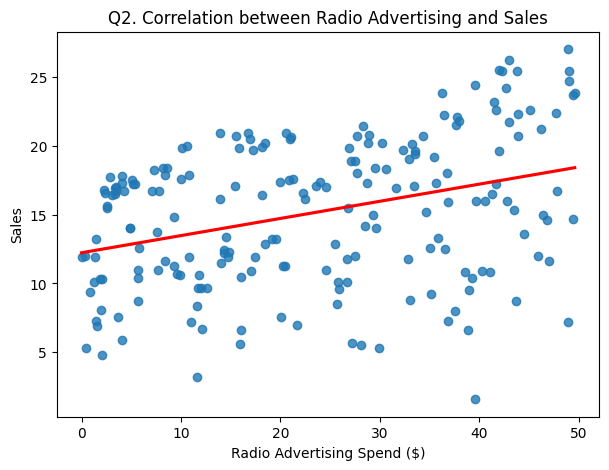

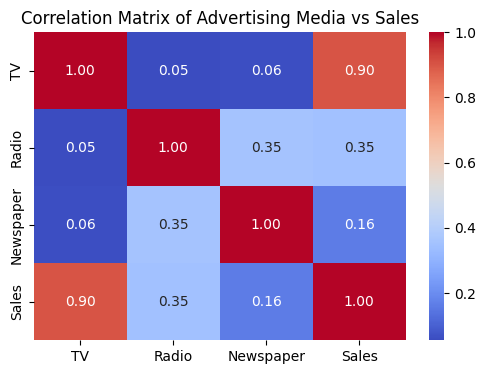

In [ ]:
# What is the correlation between radio advertising expenditure and product sales?

# Drop rows with missing values for safe plotting
df_clean = df.dropna(subset=['Radio','Sales'])

correlation_radio_sales = df_clean['Radio'].corr(df_clean['Sales'])
print(f"The correlation between radio advertising expenditure and product sales is: {correlation_radio_sales:.2f}")

plt.figure(figsize=(7,5))
sns.regplot(x='Radio', y='Sales', data=df_clean, ci=None, line_kws={"color":"red"})
plt.title("Q2. Correlation between Radio Advertising and Sales")
plt.xlabel("Radio Advertising Spend ($)")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df_clean[['TV','Radio','Newspaper','Sales']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Advertising Media vs Sales")
plt.show()


In [ ]:
# Which advertising medium has the highest impact on sales based on the dataset?

# Check for missing values
print("Missing values per column:")
print(df[['TV','Radio','Newspaper','Sales']].isnull().sum())

# Drop rows with missing values
df_clean = df.dropna(subset=['TV','Radio','Newspaper','Sales'])

# Normalized regression coefficients (better measure of impact)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[['TV','Radio','Newspaper']])
y = df_clean['Sales']

model_scaled = LinearRegression().fit(X_scaled, y)
coeffs = pd.DataFrame({
    'Feature': ['TV','Radio','Newspaper'],
    'Coefficient': model_scaled.coef_
})
print("\nRegression Coefficients (normalized data):")
print(coeffs.sort_values(by='Coefficient', ascending=False))

print("\nCorrelation with Sales:")
print(df_clean[['TV','Radio','Newspaper','Sales']].corr()['Sales'].drop('Sales'))

top_feature = coeffs.loc[coeffs['Coefficient'].idxmax(), 'Feature']
print(f"\nThe advertising medium with the highest impact on Sales is: {top_feature}")


Missing values per column:
TV           0
Radio        2
Newspaper    0
Sales        0
dtype: int64

Regression Coefficients (normalized data):
     Feature  Coefficient
0         TV     4.686237
1      Radio     1.595291
2  Newspaper    -0.000414

Correlation with Sales:
TV           0.901372
Radio        0.349728
Newspaper    0.159125
Name: Sales, dtype: float64

The advertising medium with the highest impact on Sales is: TV


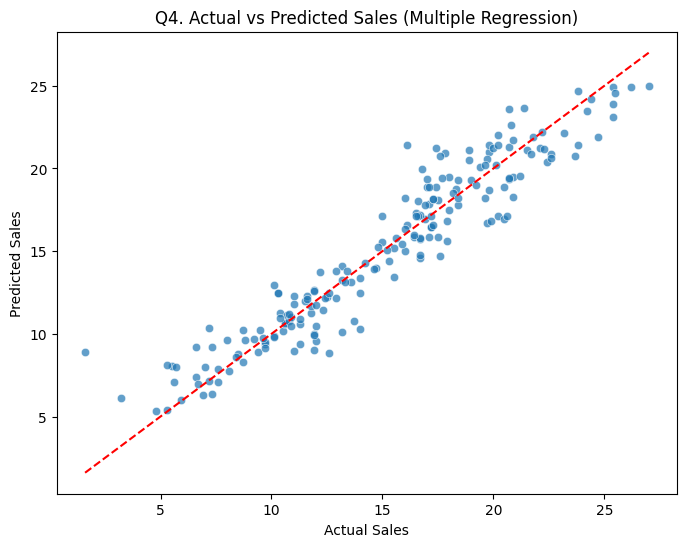

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     601.4
Date:                Sat, 16 Aug 2025   Prob (F-statistic):           6.01e-98
Time:                        17:59:10   Log-Likelihood:                -380.12
No. Observations:                 198   AIC:                             768.2
Df Residuals:                     194   BIC:                             781.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6343      0.309     15.008      0.0

In [ ]:
#Plot a linear regression line that includes all variables (TV, Radio, Newspaper) to predict Sales, and visualize the model's predictions against the actual sales values.

# Fit OLS model
model = smf.ols('Sales ~ TV + Radio + Newspaper', data=df).fit()
predictions = model.predict(df[['TV','Radio','Newspaper']])

# Scatterplot: Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Sales'], y=predictions, alpha=0.7)
plt.plot([df['Sales'].min(), df['Sales'].max()],
         [df['Sales'].min(), df['Sales'].max()],
         color='red', linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Q4. Actual vs Predicted Sales (Multiple Regression)")
plt.show()

# Show model summary
print(model.summary())


In [ ]:
# How would sales be predicted for a new set of advertising expenditures: $200 on TV, $40 on Radio, and $50 on Newspaper?
new_expenditures = pd.DataFrame({'TV': [200], 'Radio': [40], 'Newspaper': [50]})
predicted_sales = model.predict(new_expenditures)
print(f"Predicted sales for the new expenditures: ${predicted_sales[0]:.2f}")

Predicted sales for the new expenditures: $19.82


In [ ]:
# How does the performance of the linear regression model change when the dataset is normalized?
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Drop rows with missing values (to avoid NaN issues)
df_clean = df.dropna(subset=['TV','Radio','Newspaper','Sales'])

# Features and target
X = df_clean[['TV', 'Radio', 'Newspaper']]
y = df_clean['Sales']

# Model before normalization
model_orig = LinearRegression().fit(X, y)
r2_before = model_orig.score(X, y)

# Model after normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model_scaled = LinearRegression().fit(X_scaled, y)
r2_after = model_scaled.score(X_scaled, y)

print(f"Q6. R² before normalization: {r2_before:.4f}")
print(f"Q6. R² after normalization:  {r2_after:.4f}")

Q6. R² before normalization: 0.9029
Q6. R² after normalization:  0.9029


In [ ]:
# What is the impact on the sales prediction when only radio and newspaper advertising expenditures are used as predictors?
from sklearn.linear_model import LinearRegression

# Drop rows with missing values
df_clean = df.dropna(subset=['Radio','Newspaper','Sales'])

# Features and target
X_rn = df_clean[['Radio','Newspaper']]
y = df_clean['Sales']

# Train the model
model_rn = LinearRegression().fit(X_rn, y)

# Performance
r2_rn = model_rn.score(X_rn, y)
print(f"Q7. R² using only Radio + Newspaper: {r2_rn:.4f}")

# Example prediction
new_data_rn = pd.DataFrame({'Radio': [40], 'Newspaper': [50]})
predicted_sales_rn = model_rn.predict(new_data_rn)
print(f"Predicted Sales (Radio=40, Newspaper=50): {predicted_sales_rn[0]:.2f}")


Q7. R² using only Radio + Newspaper: 0.1237
Predicted Sales (Radio=40, Newspaper=50): 17.31
